# What Buys Accuracy: More Sensors, More Years, or More Indices?

**Tawau Hills Park (Taman Bukit Tawau), Sabah, Malaysian Borneo**

Tawau Hills Park protects about 280 km² of lowland and hill dipterocarp rainforest on
the slopes of an extinct volcano. Outside its boundary the forest gives way to oil palm
plantations, some reaching the park edge. Telling the two apart from space is a routine
question, and in this part of Borneo also a hard one: of the ~220 Sentinel-2 scenes
acquired over the park every year, only a handful are less than 20% cloudy.

That makes it a good place to ask what actually improves a classification when the sky
is against you. This notebook runs the same classification six times — **Sentinel-2
alone, Sentinel-1 alone, and both together**, each over **one year (2024) and over six
(2020-2025)** — on the same points, with the same split, and compares them:

| | Sentinel-2 | Sentinel-1 | Sentinel-2 + Sentinel-1 |
|---|---|---|---|
| **2024** | ? | ? | ? |
| **2020-2025** | ? | ? | ? |

Radar sees through clouds but not colour; optical sees colour but not through clouds, so
combining them should help. Compositing six years instead of one should help too, for a
different reason: every season pools six times more scenes, so the clouds the Scene
Classification Layer misses get outvoted. The question is whether the two remedies add up,
or whether one of them makes the other unnecessary — if six years of Sentinel-2 are enough,
the radar half of the pipeline is work you do not need to do.

A last section asks the same question of a third knob: **more indices per sensor**.

It uses the **multi-sensor feature stacks** added to `LandCoverClassifier` in
ndvi2gif 1.6.0: several `NdviSeasonality` objects, one per sensor, combined into one
classification.

```{note}
Running this notebook end to end takes roughly 45 minutes: seven random forests over
stacks of up to 96 bands, most of them composited from six years of imagery.
```

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='geemap.conversion')

import ee
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import chi2
from urllib.request import urlopen
from PIL import Image
from io import BytesIO

from ndvi2gif import NdviSeasonality, LandCoverClassifier

# ee.Authenticate()          # only the first time
ee.Initialize(project='your-project-id')
print('✓ Earth Engine initialised')

✓ Earth Engine initialised


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


## 2. Study area

The park boundary comes from the World Database on Protected Areas, available in Earth
Engine. Its WDPA name is *Tawau Hill Park* — filter on the exact name, since the
neighbouring *Tawau Protection Forest* would also match a partial search. The study area
is the bounding box of the park plus 8 km, so that it takes in the plantations around it.

In [2]:
park = (ee.FeatureCollection('WCMC/WDPA/current/polygons')
        .filter(ee.Filter.eq('NAME', 'Tawau Hill Park'))
        .geometry())
area = park.buffer(8000, 100).bounds(100)

print(f"Park:       {park.area(100).divide(1e6).getInfo():6.0f} km²")
print(f"Study area: {area.area(100).divide(1e6).getInfo():6.0f} km²")

Park:          280 km²


Study area:   1702 km²


## 3. How cloudy is it?

With `cloud_filter=True` (the default), `NdviSeasonality` cleans Sentinel-2 in two
steps: it drops whole scenes whose metadata reports more than `max_cloud_cover` percent of
clouds (20 by default), and then masks the cloudy pixels of the remaining scenes with the
Scene Classification Layer (`scl_mask=True`). Let's see what the default leaves for monthly
composites of 2024 over the park, compared with keeping every scene and relying on the pixel
mask alone (`max_cloud_cover=100`).

In [3]:
YEAR = 2024
MONTHS = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

def monthly_coverage(max_cloud_cover):
    ns = NdviSeasonality(roi=area, sat='S2', periods=12, start_year=YEAR,
                         end_year=YEAR, index='ndvi', key='median',
                         cloud_filter=True, max_cloud_cover=max_cloud_cover)
    scenes = ee.List([ns.ndvi_col.filterDate(f'{YEAR}{s}', f'{YEAR}{e}').size()
                      for s, e in ns.period_dates])
    covered = ee.List([
        ns.get_period_composite(YEAR, i).mask()
          .reduceRegion(ee.Reducer.mean(), area, 500, maxPixels=1e10)
          .values().get(0)
        for i in range(12)
    ])
    scenes, covered = ee.List([scenes, covered]).getInfo()
    return scenes, [c or 0 for c in covered]

strict = monthly_coverage(max_cloud_cover=20)
relaxed = monthly_coverage(max_cloud_cover=100)

coverage = pd.DataFrame({
    'scenes ≤20% cloud': strict[0],
    'area covered': [f'{c:.0%}' for c in strict[1]],
    'all scenes': relaxed[0],
    'area covered (pixel mask only)': [f'{c:.0%}' for c in relaxed[1]],
}, index=MONTHS)
coverage

There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


There we go again...
Applying cloud filter to Sentinel-2: max 100% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


,scenes ≤20% cloud,area covered,all scenes,area covered (pixel mask only)
Jan,0,0%,44,95%
Feb,5,71%,44,100%
Mar,1,29%,48,100%
Apr,2,20%,47,85%
May,3,57%,48,96%
Jun,2,0%,42,72%
Jul,7,87%,48,96%
Aug,1,0%,48,69%
Sep,7,55%,48,92%
Oct,2,0%,48,83%


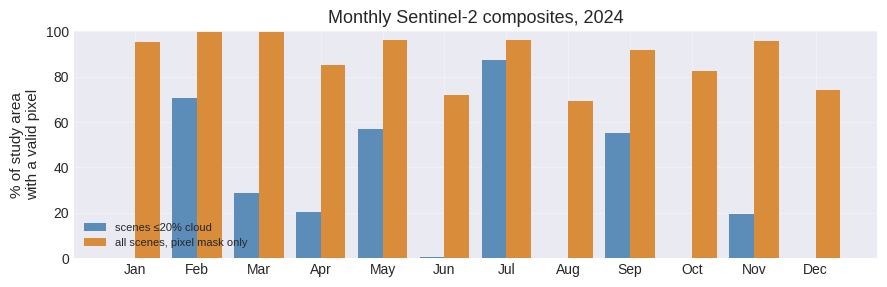

In [4]:
x = np.arange(12)
fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(x - 0.2, [100 * c for c in strict[1]], 0.4, color='#5c8db8', label='scenes ≤20% cloud')
ax.bar(x + 0.2, [100 * c for c in relaxed[1]], 0.4, color='#d98c3a', label='all scenes, pixel mask only')
ax.set_xticks(x, MONTHS)
ax.set_ylabel('% of study area\nwith a valid pixel')
ax.set_ylim(0, 100)
ax.set_title(f'Monthly Sentinel-2 composites, {YEAR}')
ax.legend(loc='lower left', fontsize=8, frameon=False)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
plt.tight_layout()

With the default threshold some months have no scene at all and most of the rest cover
only part of the area. Since ndvi2gif 1.5.1 an empty month is kept as a fully masked
band, so the months stay in their place, and `LandCoverClassifier` leaves those bands
out of the feature stack. The partial months are the real problem: **a pixel masked in
any band of the stack is dropped from the training samples and left unclassified in the
map.** A stack of twelve patchy months would classify only the pixels that happen to be
clear in all of them.

Keeping every scene and masking clouds pixel by pixel does much better, because the
clear patches of 40-60 scenes a month add up. Monthly composites still have holes in
the cloudiest months, though, and a season fills them. That is why the 2024 stack below
uses **seasonal medians of all scenes with the pixel mask** (`max_cloud_cover=100`). The
price is the haze and cloud edges the Scene Classification Layer misses, which a median
dampens but does not remove.

Note that `cloud_filter=False` is *not* the way to keep every scene: it switches off the
pixel mask as well, and the composites fill up with clouds.

## 4. One year or six?

Everything above is the arithmetic of a single year. Over six, it changes.

`get_year_composite()` returns one image per year, and every one of them carries the same
band names — `winter`, `spring`, `summer`, `autumn`. So the median of that collection is
the per-pixel median of each season across the years: one "typical summer" per pixel,
built from six summers instead of one. A year whose summer was cloudy over a given pixel
is masked there and simply does not vote.

That is the compositing ndvi2gif is built around, and it changes two things at once.
Each seasonal composite pools roughly six times more scenes, so the haze and cloud
shadows the SCL misses are outvoted instead of merely dampened; and a pixel needs a clear
view in only *one* of the six years to make it into the stack, so the holes close.

It also lets us put the scene-level cloud filter back. `max_cloud_cover=100` was a
concession to scarcity within one year; with six there is no scarcity, so the worst
scenes — the ones that contribute most of the haze — can go back in the bin. The
six-year stacks below use `max_cloud_cover=50`.

In [5]:
def seasonal_median(processor, indices, prefix=''):
    """Median across years of every period, one band per index and period.

    get_year_composite() gives one image per year, all with the same band
    names, so median() on that collection is the per-pixel median of each
    period across the years. Masked periods do not vote, which is what closes
    the holes.
    """
    bands = []
    original = processor.index
    try:
        for index in indices:
            processor.index = index
            composite = processor.get_year_composite().median()
            bands.append(
                composite.select(processor.period_names)
                         .rename([f'{prefix}{index}_{p}' for p in processor.period_names])
            )
    finally:
        processor.index = original
    return ee.Image.cat(bands)


def add_statistics(stack, groups):
    """The four temporal statistics create_feature_stack(include_statistics=True) adds."""
    stats = []
    for group in groups:
        bands = stack.select(f'{group}_.*')
        stats += [bands.reduce(ee.Reducer.mean()).rename(f'{group}_mean'),
                  bands.reduce(ee.Reducer.stdDev()).rename(f'{group}_std'),
                  bands.reduce(ee.Reducer.max()).rename(f'{group}_max'),
                  bands.reduce(ee.Reducer.min()).rename(f'{group}_min')]
    return stack.addBands(ee.Image.cat(stats))

The two sensors, over each time span:

- **Sentinel-2**: seasonal medians (`periods=4`) of NDVI, NDWI and NDMI — greenness,
  surface water and canopy moisture.
- **Sentinel-1**: monthly medians (`periods=12`) of VV and VH backscatter, which
  respond to canopy structure: the regular rows and open canopy of a plantation
  scatter differently from the multi-layered canopy of a rainforest. ndvi2gif applies
  its analysis-ready preprocessing: a Refined Lee speckle filter and radiometric terrain
  correction, which matters here — the park climbs the slopes of an extinct volcano,
  and a slope facing the radar looks brighter than the same forest on flat ground.

Both sensors are 10 m, so they combine without resampling (section 13 shows what happens
when they differ).

In [6]:
S2_INDICES = ['ndvi', 'ndwi', 'ndmi']
S1_INDICES = ['vv', 'vh']

def stacks_for(start_year, end_year, max_cloud_cover):
    """The three feature stacks (S2, S1, both) of one time span."""
    s2 = NdviSeasonality(roi=area, sat='S2', periods=4, index='ndvi', key='median',
                         max_cloud_cover=max_cloud_cover,
                         start_year=start_year, end_year=end_year)
    s1 = NdviSeasonality(roi=area, sat='S1', periods=12, index='vh', key='median',
                         start_year=start_year, end_year=end_year)

    stack_s2 = add_statistics(seasonal_median(s2, S2_INDICES, 'S2_'),
                              [f'S2_{i}' for i in S2_INDICES])
    stack_s1 = add_statistics(seasonal_median(s1, S1_INDICES, 'S1_'),
                              [f'S1_{i}' for i in S1_INDICES])

    return {'Sentinel-2': (stack_s2.clip(area), [s2]),
            'Sentinel-1': (stack_s1.clip(area), [s1]),
            'Sentinel-2 + Sentinel-1': (ee.Image.cat([stack_s2, stack_s1]).clip(area), [s2, s1])}

SPANS = {'2024': stacks_for(2024, 2024, max_cloud_cover=100),
         '2020-2025': stacks_for(2020, 2025, max_cloud_cover=50)}

There we go again...
Applying cloud filter to Sentinel-2: max 100% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering
There we go again...
Using all Sentinel-1 orbits (ascending + descending).
Applying S1 ARD preprocessing:
  - Speckle filter: REFINED_LEE
  - Terrain correction: True
  - Terrain model: VOLUME


Year 2024: 4/4 periods with data using ndvi index


Year 2024: 4/4 periods with data using ndwi index


Year 2024: 4/4 periods with data using ndmi index


Year 2024: 12/12 periods with data using vv index


...

Year 2021: 12/12 periods with data using vh index


Year 2022: 12/12 periods with data using vh index


Year 2023: 12/12 periods with data using vh index


Year 2024: 12/12 periods with data using vh index


Year 2025: 12/12 periods with data using vh index


In [7]:
def full_coverage(stack, scale=300):
    """Share of the study area where *every* band of the stack has a value."""
    return (stack.mask().reduce(ee.Reducer.min())
            .reduceRegion(ee.Reducer.mean(), area, scale, maxPixels=1e10)
            .values().get(0).getInfo())

pd.Series({span: f'{full_coverage(SPANS[span]["Sentinel-2 + Sentinel-1"][0]):.1%}'
           for span in SPANS},
          name='area with a value in every band')

2024         97.4%
2020-2025    99.7%
Name: area with a value in every band, dtype: object

Six years close the holes: the share of the study area with a value in **every** band of
the combined stack goes from 97.4% to 99.7%. The remaining 0.3% is the summit, where the
cloud almost never lifts.

That is the gap-filling half of the story. The other half — whether the composites are
also *better*, not merely more complete — is what the rest of the notebook measures.

## 5. Reference labels

There is no field survey here, so the reference comes from two global maps:

- **[ESA WorldCover 2021](https://developers.google.com/earth-engine/datasets/catalog/ESA_WorldCover_v200)** (10 m) for tree cover, mangroves, water, built-up land and
  grassland/cropland.
- **[Global oil palm map](https://developers.google.com/earth-engine/datasets/catalog/BIOPAMA_GlobalOilPalm_v1)** (Descals et al., 2021, 10 m, 2019) for industrial and
  smallholder plantations. WorldCover labels oil palm as tree cover, so it is carved out
  of the forest class.

| Class | Value | Source |
|---|---|---|
| Natural forest | 0 | WorldCover tree cover, not oil palm |
| Oil palm | 1 | Global oil palm map (industrial + smallholder) |
| Mangrove | 2 | WorldCover |
| Water | 3 | WorldCover |
| Built-up | 4 | WorldCover |
| Grassland / cropland | 5 | WorldCover |

400 points are drawn per class, so rare classes such as built-up land are represented as
well as the forest. That number is not arbitrary: the whole point of this notebook is to
compare six classifications, and a comparison is only worth making if the sample can tell
the results apart. With 2400 points, 30% of them held out, the standard error of an
overall accuracy around 0.75 is about 1.6 points — small enough for the differences we
are after. With the 150 points per class a single classification would get away with, it
would be nearly 3 points, and most of the table would be noise.

Keep in mind what this measures: agreement with two maps made for other years (2019 and
2021), including their own errors. It is a fair yardstick to *compare* the six stacks,
not a certified accuracy.

In [8]:
CLASSES = ['Natural forest', 'Oil palm', 'Mangrove', 'Water', 'Built-up',
           'Grassland / cropland']
PALETTE = ['1b5e20', 'c0ca33', '00897b', '1e88e5', 'e53935', 'ffb74d']
POINTS_PER_CLASS = 400

worldcover = ee.ImageCollection('ESA/WorldCover/v200').first()
oil_palm = (ee.ImageCollection('BIOPAMA/GlobalOilPalm/v1')
            .select('classification').mosaic().lte(2))  # 1 industrial, 2 smallholder

labels = (ee.Image(-1)
          .where(worldcover.eq(10).And(oil_palm.Not()), 0)
          .where(oil_palm, 1)
          .where(worldcover.eq(95), 2)
          .where(worldcover.eq(80), 3)
          .where(worldcover.eq(50), 4)
          .where(worldcover.eq(30).Or(worldcover.eq(40)), 5)
          .rename('class'))
labels = labels.updateMask(labels.gte(0)).toInt()

points = labels.stratifiedSample(numPoints=POINTS_PER_CLASS, classBand='class',
                                 region=area, scale=30, seed=42, geometries=True)
counts = points.aggregate_histogram('class').getInfo()
pd.Series({CLASSES[int(k)]: v for k, v in counts.items()}, name='points')

Natural forest          400
Oil palm                400
Mangrove                400
Water                   400
Built-up                400
Grassland / cropland    400
Name: points, dtype: int64

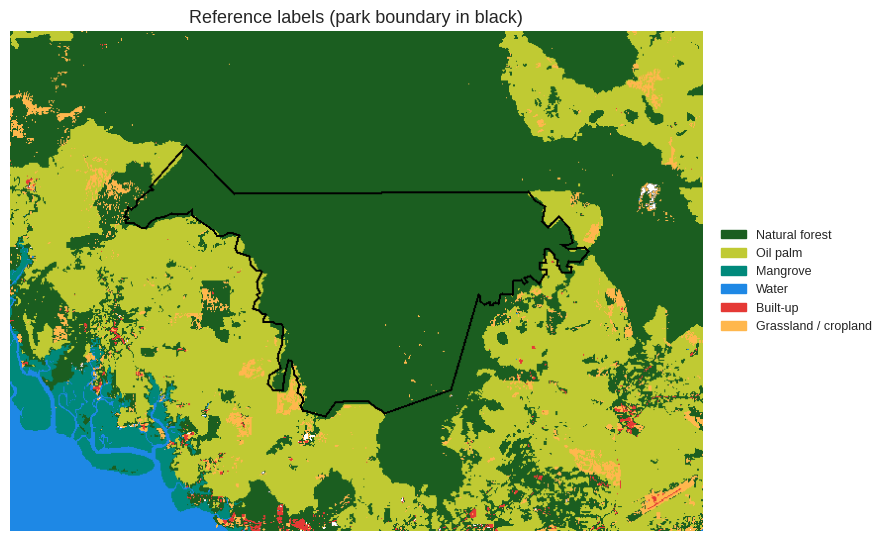

In [9]:
def thumbnail(image, vis, dimensions=700):
    # Static PNG of an ee.Image over the study area
    url = image.visualize(**vis).getThumbURL(
        {'region': area, 'dimensions': dimensions, 'format': 'png'})
    return Image.open(BytesIO(urlopen(url).read()))

def show_classes(ax, img, title):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')

class_vis = {'min': 0, 'max': 5, 'palette': PALETTE}
park_outline = ee.Image().byte().paint(park, 1, 2).visualize(palette=['000000'])
legend = [Patch(color='#' + c, label=n) for c, n in zip(PALETTE, CLASSES)]

fig, ax = plt.subplots(figsize=(9, 7))
show_classes(ax, thumbnail(labels.visualize(**class_vis).blend(park_outline), {}),
             'Reference labels (park boundary in black)')
ax.legend(handles=legend, loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=9, frameon=False)
plt.tight_layout()

## 6. Same points, same split, six classifiers

The six classifiers are trained and validated on the **same points**: those where every
band of every stack has a value. Otherwise each would be scored on a different sample and
the comparison would not be fair. A single-sensor stack is a subset of the combined one,
so the points valid in both combined stacks are valid in all six.

The result is then **materialized** — pulled to the client and sent back as a literal
collection. Without that, `usable` stays a recipe that says "sample those two big stacks",
and every one of the six runs below would recompute the six-year composites from scratch
just to find out which points to use. It is the difference between minutes and an hour.

In [10]:
def materialize(fc):
    """Bring a computed FeatureCollection to the client and send it back as a literal.

    Downstream operations then carry the points themselves instead of the
    recipe that produced them, so nothing upstream is recomputed.
    """
    info = fc.getInfo()
    return ee.FeatureCollection([
        ee.Feature(ee.Geometry.Point(f['geometry']['coordinates']), f['properties'])
        for f in info['features']
    ])

everything = ee.Image.cat([SPANS['2024']['Sentinel-2 + Sentinel-1'][0],
                           SPANS['2020-2025']['Sentinel-2 + Sentinel-1'][0]])

usable = materialize(
    everything.sampleRegions(collection=points, properties=['class'],
                             scale=10, geometries=True).select(['class'])
)
print(f"{usable.size().getInfo()} of {points.size().getInfo()} points usable by all six stacks")

2375 of 2400 points usable by all six stacks


In [11]:
runs = {}
for span, stacks in SPANS.items():
    for sensors, (stack, processors) in stacks.items():
        clf = LandCoverClassifier(processors)
        clf.feature_stack = stack
        clf.add_training_data(training_points=usable, class_property='class')
        clf.classify_supervised(algorithm='random_forest', params={'numberOfTrees': 100})
        runs[(span, sensors)] = clf

LandCoverClassifier initialized for S2
Period: 2024-2024, 4 periods/year
Loading training data...


Training data loaded: 2375 samples


Split: 1654 training, 721 validation
Training random_forest classifier...
random_forest classification complete


Overall Accuracy: 0.738
Kappa: 0.685
LandCoverClassifier initialized for S1
Period: 2024-2024, 12 periods/year
Loading training data...


Training data loaded: 2375 samples


...

Split: 1654 training, 721 validation
Training random_forest classifier...
random_forest classification complete


Overall Accuracy: 0.660
Kappa: 0.591
LandCoverClassifier initialized for S2, S1
Period: 2020-2025, 4 periods/year
Feature stack at 10 m (native: S2 10 m, S1 10 m)
Loading training data...


Training data loaded: 2375 samples


Split: 1654 training, 721 validation
Training random_forest classifier...
random_forest classification complete


Overall Accuracy: 0.818
Kappa: 0.781


## 7. Accuracy

Each classifier trains on 70% of the points and is validated on the other 30%. The split
is drawn on the points before the stack is read, so all six are scored on exactly the same
validation sample.

In [12]:
summary = pd.DataFrame(
    [{'span': span, 'sensors': sensors,
      'features': clf.feature_stack.bandNames().size().getInfo(),
      'overall accuracy': clf.accuracy_results['overall_accuracy'],
      'kappa': clf.accuracy_results['kappa']}
     for (span, sensors), clf in runs.items()]
).set_index(['span', 'sensors'])
summary.style.format({'features': '{:.0f}', 'overall accuracy': '{:.3f}', 'kappa': '{:.3f}'})

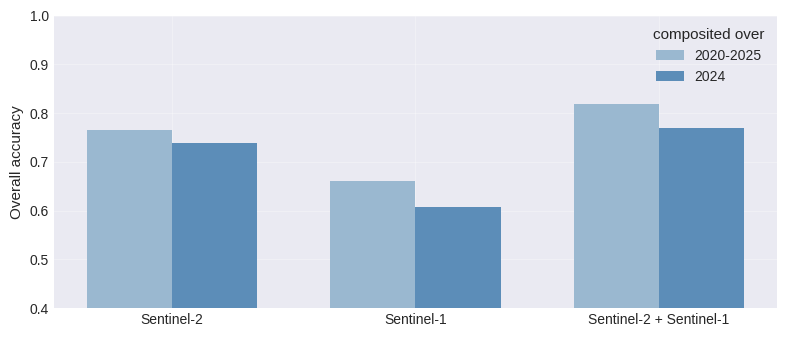

In [13]:
oa = summary['overall accuracy'].unstack('sensors')
oa = oa[['Sentinel-2', 'Sentinel-1', 'Sentinel-2 + Sentinel-1']]

fig, ax = plt.subplots(figsize=(8, 3.5))
x = np.arange(len(oa.columns))
for i, (span, row) in enumerate(oa.iterrows()):
    ax.bar(x + (i - 0.5) * 0.35, row.values, 0.35,
           color=['#9ab8d0', '#5c8db8'][i], label=span)
ax.set_xticks(x, oa.columns)
ax.set_ylabel('Overall accuracy')
ax.set_ylim(0.4, 1.0)
ax.legend(frameon=False, title='composited over')
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
plt.tight_layout()

In [14]:
per_class = pd.DataFrame({
    f'{span}\n{sensors}': clf.get_accuracy_report().set_index('Class')['ProducerAccuracy'].drop('Overall')
    for (span, sensors), clf in runs.items()
})
per_class.index = [CLASSES[int(i)] for i in per_class.index]
per_class.style.format('{:.2f}').set_caption("Producer's accuracy per class")

,2024 Sentinel-2,2024 Sentinel-1,2024 Sentinel-2 + Sentinel-1,2020-2025 Sentinel-2,2020-2025 Sentinel-1,2020-2025 Sentinel-2 + Sentinel-1
Natural forest,0.59,0.48,0.65,0.63,0.57,0.69
Oil palm,0.63,0.71,0.75,0.64,0.78,0.80
Mangrove,0.95,0.82,0.94,0.94,0.82,0.94
Water,0.96,0.95,0.94,0.97,0.95,0.96
Built-up,0.91,0.34,0.93,0.93,0.30,0.95
Grassland / cropland,0.34,0.30,0.37,0.43,0.50,0.53


Read down the columns and the second sensor wins every time: **0.738 to 0.770** in 2024,
**0.764 to 0.818** over six years. Read across the rows and the six years win too, and by
a comparable amount — +0.026 for Sentinel-2 alone, +0.053 for Sentinel-1, +0.048 for the
combination. The best cell of the table, six years of both sensors, reaches **0.818**.

The per-class table says where each remedy acts, and they are not the same place:

- **Oil palm and natural forest are what the second sensor rescues.** Palm goes from 0.63
  to 0.75 in 2024 and from 0.64 to 0.80 over six years; forest from 0.59 to 0.65 and from
  0.63 to 0.69. This is the expected result — the canopy of a rainforest and that of a
  mature plantation are both closed and green, and it is structure, which only the radar
  sees, that separates them.
- **Grassland / cropland is the opposite: it is a matter of time, not of sensor.** In 2024
  it stays stuck around 0.34-0.37 whatever the sensors; over six years it climbs to 0.53,
  and Sentinel-1 alone reaches 0.50 against its own 0.30 in a single year. It is the one
  class whose *behaviour over time* is its signature — bare in one season, green in the
  next, different from year to year — so a median spanning six years describes it far
  better than one spanning one.
- **Water and mangrove are already solved** by anything with optical data (0.94-0.97) and
  stay where they were.
- **Built-up is the class radar cannot do.** Sentinel-1 alone scores 0.30-0.34 on it,
  against 0.91-0.95 for anything including Sentinel-2: a bright roof is an optical
  signature, and backscatter from a town is not that different from backscatter from
  broken terrain.

## 8. Which differences are real?

Reading a table of accuracies as a ranking is how most comparisons go wrong. All six
classifiers were validated on the same points, so the right question is not "are these two
numbers far apart" but "on how many points did they actually disagree, and did one of them
win those disagreements". That is **McNemar's test**: of the points where exactly one of the
two got it right, it asks whether the split is further from even than chance allows.

Pairing is what gives the test its power. Two accuracies with overlapping confidence
intervals can still differ significantly, because the points both models get right — most
of them — carry no information about which is better and are ignored.

In [15]:
def predictions(clf):
    """Reference and predicted class at every validation point."""
    fc = clf.validation_data.classify(clf.classifier)
    rows = fc.select(['random', 'class', 'classification']).getInfo()['features']
    return (pd.DataFrame([r['properties'] for r in rows])
              .set_index('random').sort_index())

preds = {key: predictions(clf) for key, clf in runs.items()}

def mcnemar(a, b):
    """Is b better than a on the same validation points? (chi2 with continuity correction)"""
    a, b = preds[a], preds[b].loc[preds[a].index]
    only_b = int(((a['classification'] != a['class']) & (b['classification'] == b['class'])).sum())
    only_a = int(((a['classification'] == a['class']) & (b['classification'] != b['class'])).sum())
    if only_a + only_b == 0:
        return only_a, only_b, 1.0
    stat = (abs(only_b - only_a) - 1) ** 2 / (only_a + only_b)
    return only_a, only_b, float(chi2.sf(stat, 1))

comparisons = [
    ('does the second sensor help in 2024?',      ('2024', 'Sentinel-2'),      ('2024', 'Sentinel-2 + Sentinel-1')),
    ('does the second sensor help over 6 years?', ('2020-2025', 'Sentinel-2'), ('2020-2025', 'Sentinel-2 + Sentinel-1')),
    ('do 6 years help Sentinel-2 alone?',         ('2024', 'Sentinel-2'),      ('2020-2025', 'Sentinel-2')),
    ('do 6 years help Sentinel-1 alone?',         ('2024', 'Sentinel-1'),      ('2020-2025', 'Sentinel-1')),
    ('do 6 years help the combination?',          ('2024', 'Sentinel-2 + Sentinel-1'), ('2020-2025', 'Sentinel-2 + Sentinel-1')),
    ('6 years of S2 vs 1 year of S2 + S1',        ('2024', 'Sentinel-2 + Sentinel-1'), ('2020-2025', 'Sentinel-2')),
]

rows = []
for question, a, b in comparisons:
    only_a, only_b, p = mcnemar(a, b)
    rows.append({'question': question,
                 'only the first is right': only_a,
                 'only the second is right': only_b,
                 'p': p,
                 'verdict': 'significant' if p < 0.05 else 'not significant'})
pd.DataFrame(rows).set_index('question').style.format({'p': '{:.4f}'})

,only the first is right,only the second is right,p,verdict
question,,,,
does the second sensor help in 2024?,36,59,0.0240,significant
does the second sensor help over 6 years?,21,60,0.0000,significant
do 6 years help Sentinel-2 alone?,38,57,0.0648,not significant
do 6 years help Sentinel-1 alone?,38,76,0.0005,significant
do 6 years help the combination?,25,60,0.0002,significant
6 years of S2 vs 1 year of S2 + S1,49,45,0.7570,not significant


This is where the table stops being a ranking and becomes an answer.

**The second sensor is worth it, in both spans.** In 2024, 59 validation points that
Sentinel-2 alone got wrong are fixed by adding radar against 36 broken the other way
(p = 0.024); over six years, 60 against 21 (p < 0.0001). Nothing marginal about it.

**The six years are worth it too — but not for Sentinel-2 on its own.** For the
combination, 60 points fixed against 25 broken (p = 0.0002), and for Sentinel-1 alone 76
against 38 (p = 0.0005), which fits: radar has no clouds to average away, so what six
years buy it is speckle reduction and a longer look at how each cover type varies. For
Sentinel-2 by itself, 57 against 38 is **not** significant (p = 0.065).

And the comparison the notebook was built to make:

> **One year of two sensors and six years of one are statistically indistinguishable.**
> 2024 with Sentinel-2 + Sentinel-1 (0.770) against 2020-2025 with Sentinel-2 alone
> (0.764): 45 points against 49, p = 0.76.

So there is no winner between the two investments. If you already have six years of
optical data, adding radar buys you a significant improvement; if you already have two
sensors, adding five years buys you one too. What does *not* work is expecting one of
them to substitute for the other and then stack both gains — as the next section shows,
they largely overlap.

A caveat worth keeping: this is agreement with two global maps of 2019 and 2021, so a
classification of 2024 alone is being scored against labels of *other* years, and one
built from 2020-2025 overlaps them better. If anything that biases the comparison in
favour of the six-year stacks.

## 9. Maps

A word on the size of these. Rendering a classified image means evaluating the whole
feature stack at every output pixel, and a six-year, 56-band stack asks for more memory
than a thumbnail is allowed: at 400 pixels across, Earth Engine answers
`User memory limit exceeded`. At 250 it renders in about a minute. That is a property of
the stack, not of the classification — for a full-resolution map, export the image with
`export_results()` and open the GeoTIFF, or add it to a `geemap` map, which requests one
small tile at a time.

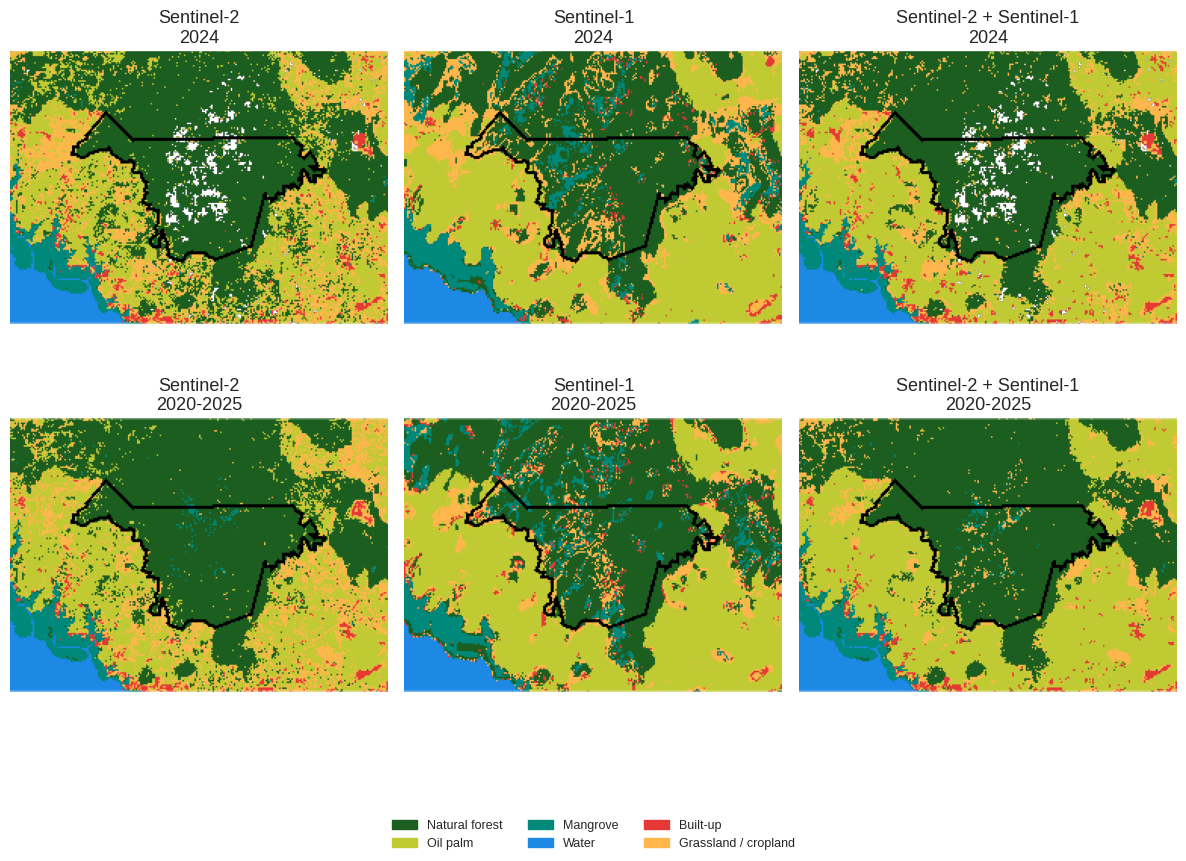

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(12, 9))
for ax, ((span, sensors), clf) in zip(axes.ravel(), runs.items()):
    img = clf.classified_image.visualize(**class_vis).blend(park_outline)
    show_classes(ax, thumbnail(img, {}, dimensions=250), f'{sensors}\n{span}')
fig.legend(handles=legend, loc='lower center', ncol=3, fontsize=9, frameon=False)
plt.tight_layout(rect=(0, 0.08, 1, 1))

The maps make the numbers concrete, and the failure modes are visible without any
statistics.

**The white holes** inside the park in the 2024 maps are pixels with no valid value in
some band of the stack — clouds the Scene Classification Layer caught, in a place with
persistent cloud cover. They vanish in the six-year maps, which is the part of the
improvement that has nothing to do with classification and everything to do with having
seen the ground at all.

**Sentinel-1 alone** paints the northern half of the park as oil palm and scatters
mangrove across the interior: without the optical bands it has no way to tell a closed
canopy on a slope from a plantation. Its map looks confident and is wrong, which is worth
remembering when a legend is all you see.

**The six-year combination** is the only map whose forest matches the boundary of the
park, and the boundary was never given to the classifier.

To explore the maps interactively, add them to a `geemap` map:

```python
import geemap
Map = geemap.Map()
Map.centerObject(area, 11)
Map.addLayer(runs[('2020-2025', 'Sentinel-2 + Sentinel-1')].classified_image, class_vis, '2020-2025, both')
Map.addLayer(runs[('2024', 'Sentinel-2')].classified_image, class_vis, '2024, S2 only', False)
Map.addLayer(park, {'color': 'black'}, 'Tawau Hill Park')
Map
```

## 10. What drives the classification

`get_feature_importance()` ranks the bands of the stack by how much the random forest
relied on them. Comparing the two combined stacks shows what changes when the composites
stop being about one particular year.

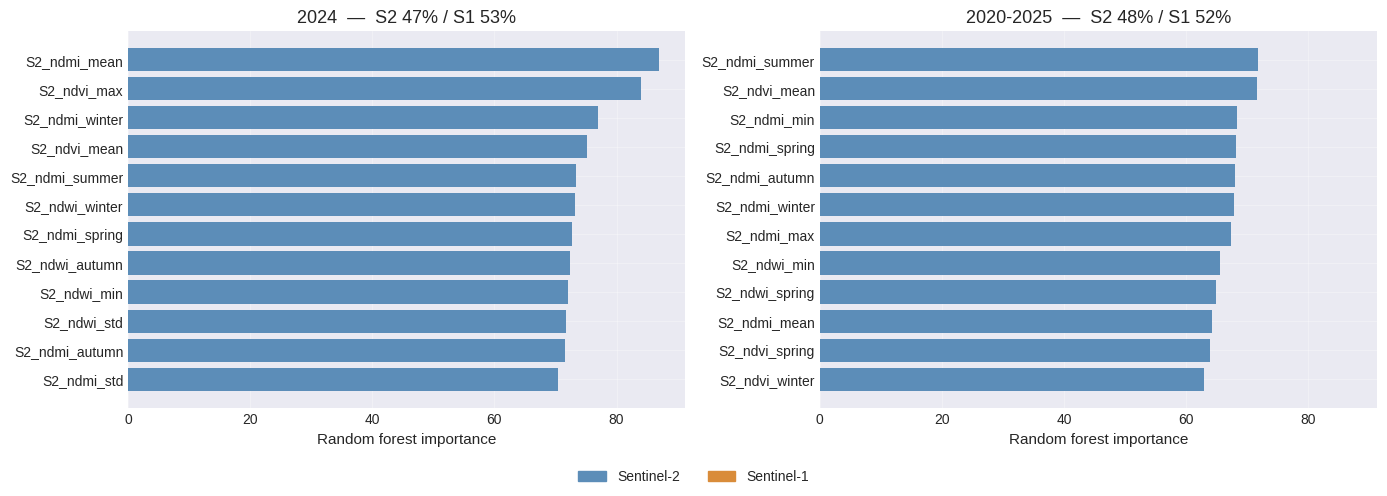

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for ax, span in zip(axes, SPANS):
    importance = pd.Series(runs[(span, 'Sentinel-2 + Sentinel-1')].get_feature_importance())
    top = importance.head(12)[::-1]
    ax.barh(top.index, top.values,
            color=['#5c8db8' if n.startswith('S2_') else '#d98c3a' for n in top.index])
    share = importance.groupby(importance.index.str.split('_').str[0]).sum()
    share = (share / share.sum())
    ax.set_title(f"{span}  —  S2 {share.get('S2', 0):.0%} / S1 {share.get('S1', 0):.0%}")
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
axes[0].set_xlabel('Random forest importance')
axes[1].set_xlabel('Random forest importance')
fig.legend(handles=[Patch(color='#5c8db8', label='Sentinel-2'),
                    Patch(color='#d98c3a', label='Sentinel-1')],
           loc='lower center', ncol=2, frameon=False)
plt.tight_layout(rect=(0, 0.06, 1, 1))

The ranking says something the accuracies do not, and it is the key to the section that
follows.

**Not one of the twelve most important features is a radar band** — in either span. The
top of the list is NDMI and NDVI, moisture and greenness, seasonal and aggregated.

**And yet radar carries about half of the total importance**: 53% in 2024, 52% over six
years. The two statements are compatible because there are 32 radar features and 24
optical ones, and the importance of the radar is spread thinly across all of them while
the optical importance concentrates in a few. Each individual backscatter band is noisy
and none is decisive; together they add up to as much as the optical half.

That is the signature of information that is *diffuse* rather than *absent*, and it is
why dropping "unimportant" features by a per-feature threshold would remove the radar
entirely — and cost the five points of accuracy it is worth.

## 11. Does adding indices help?

The third knob. The Sentinel-2 stack so far carries three indices; here it carries eight,
adding EVI and SAVI (greenness corrected for atmosphere and for soil background), NBR and
MNDWI (burn and water), and NDBI (built-up). The rest of the setup is untouched: same
years, same points, same split, same forest.

A random forest picks its own features, so more of them rarely hurts. The question is
whether it helps enough to be worth the extra computation — and indices built from the
same few bands are strongly correlated, so there is less new information here than the
count suggests.

In [18]:
S2_MORE = ['ndvi', 'ndwi', 'ndmi', 'evi', 'savi', 'nbr', 'mndwi', 'ndbi']

s2_more = NdviSeasonality(roi=area, sat='S2', periods=4, index='ndvi', key='median',
                          max_cloud_cover=50, start_year=2020, end_year=2025)
stack_more = add_statistics(seasonal_median(s2_more, S2_MORE, 'S2_'),
                            [f'S2_{i}' for i in S2_MORE]).clip(area)

clf_more = LandCoverClassifier([s2_more])
clf_more.feature_stack = stack_more
clf_more.add_training_data(training_points=usable, class_property='class')
clf_more.classify_supervised(algorithm='random_forest', params={'numberOfTrees': 100})

runs[('2020-2025', 'Sentinel-2, 8 indices')] = clf_more
preds[('2020-2025', 'Sentinel-2, 8 indices')] = predictions(clf_more)

# And the missing cell of the design: the fuller optical stack with the radar
# on top. Sentinel-1 is left exactly as in the main table, so the only thing
# that changes between this run and the previous one is the radar
stack_s1, (s1_proc,) = SPANS['2020-2025']['Sentinel-1']
clf_more_both = LandCoverClassifier([s2_more, s1_proc])
clf_more_both.feature_stack = ee.Image.cat([stack_more, stack_s1])
clf_more_both.add_training_data(training_points=usable, class_property='class')
clf_more_both.classify_supervised(algorithm='random_forest', params={'numberOfTrees': 100})

runs[('2020-2025', 'Sentinel-2 8 indices + Sentinel-1')] = clf_more_both
preds[('2020-2025', 'Sentinel-2 8 indices + Sentinel-1')] = predictions(clf_more_both)

base = runs[('2020-2025', 'Sentinel-2')]
both = runs[('2020-2025', 'Sentinel-2 + Sentinel-1')]

rows = []
for name, clf in [('Sentinel-2, 3 indices', base),
                  ('Sentinel-2, 8 indices', clf_more),
                  ('Sentinel-2 + Sentinel-1, 3 indices', both),
                  ('Sentinel-2 8 indices + Sentinel-1', clf_more_both)]:
    rows.append({'stack': name,
                 'features': clf.feature_stack.bandNames().size().getInfo(),
                 'overall accuracy': clf.accuracy_results['overall_accuracy'],
                 'kappa': clf.accuracy_results['kappa']})
display(pd.DataFrame(rows).set_index('stack').style.format(
    {'features': '{:.0f}', 'overall accuracy': '{:.3f}', 'kappa': '{:.3f}'}))

# The two ways of adding information to the same six-year Sentinel-2 stack,
# against each other and against the baseline
extra = [
    ('do five more indices help?',
     ('2020-2025', 'Sentinel-2'), ('2020-2025', 'Sentinel-2, 8 indices')),
    ('8 optical indices vs a second sensor',
     ('2020-2025', 'Sentinel-2 + Sentinel-1'), ('2020-2025', 'Sentinel-2, 8 indices')),
    ('does the radar still help on top of 8 indices?',
     ('2020-2025', 'Sentinel-2, 8 indices'), ('2020-2025', 'Sentinel-2 8 indices + Sentinel-1')),
    ('do the 5 indices still help on top of the radar?',
     ('2020-2025', 'Sentinel-2 + Sentinel-1'), ('2020-2025', 'Sentinel-2 8 indices + Sentinel-1')),
]
pd.DataFrame([
    {'question': q, 'only the first is right': a, 'only the second is right': b,
     'p': pv, 'verdict': 'significant' if pv < 0.05 else 'not significant'}
    for q, x, y in extra for a, b, pv in [mcnemar(x, y)]
]).set_index('question').style.format({'p': '{:.4f}'})

There we go again...
Applying cloud filter to Sentinel-2: max 50% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering


Year 2020: 4/4 periods with data using ndvi index


Year 2021: 4/4 periods with data using ndvi index


Year 2022: 4/4 periods with data using ndvi index


Year 2023: 4/4 periods with data using ndvi index


...

Training data loaded: 2375 samples


Split: 1654 training, 721 validation
Training random_forest classifier...
random_forest classification complete


Overall Accuracy: 0.834
Kappa: 0.800


,features,overall accuracy,kappa
stack,,,
"Sentinel-2, 3 indices",24,0.764,0.716
"Sentinel-2, 8 indices",64,0.817,0.780
"Sentinel-2 + Sentinel-1, 3 indices",56,0.818,0.781
Sentinel-2 8 indices + Sentinel-1,96,0.834,0.800


,only the first is right,only the second is right,p,verdict
question,,,,
do five more indices help?,26,64,0.0001,significant
8 optical indices vs a second sensor,49,48,1.0000,not significant
does the radar still help on top of 8 indices?,17,29,0.1048,not significant
do the 5 indices still help on top of the radar?,27,38,0.2148,not significant


The third knob works, and then it stops working, which is the most useful result in the
notebook.

**Five more indices help.** Eight optical indices over six years reach **0.824** against
0.764 for three — 64 points fixed against 26, p = 0.0001. That is a real gain, and it
comes from a single sensor and the same six years.

**It is the same gain as adding the radar.** Eight optical indices against three indices
plus Sentinel-1: 49 points against 48, **p = 1.0000**. A dead heat, to the point of
comedy.

**And the two do not add up.** Once the stack carries eight indices, the radar no longer
helps significantly (p = 0.10); once it carries the radar, the five extra indices no
longer help either (p = 0.21). The best combination of everything, 0.825, is one
thousandth above the best without radar.

So the three knobs — a second sensor, more years, more indices — are not three
independent gains to be stacked. They are three ways of reaching the same ceiling of
about 0.82, and the cheapest one wins. Here that is five more indices on data you already
have.

## 12. Taking the model elsewhere

`export_model()` writes what is needed to repeat the classification or to re-fit it
outside Earth Engine: a JSON with the full configuration (processors, feature stack,
training setup, algorithm and parameters), the model as Earth Engine describes it — every
tree of the random forest as text, the feature importance, the out-of-bag error — and the
accuracy; and a CSV with every sample, its coordinates, class, features and split.

In [19]:
best = runs[('2020-2025', 'Sentinel-2 + Sentinel-1')]
paths = best.export_model('results/tawau_s2_s1_rf')

import json
model = json.load(open(paths['model']))
print('Algorithm: ', model['classifier']['algorithm'], model['classifier']['parameters'])
print('Features:  ', len(model['features']), model['features'][:3], '...')
print('OOB error: ', round(model['classifier']['explain']['outOfBagErrorEstimate'], 3))
print()
print(model['classifier']['explain']['trees'][0][:600], '...')

Model written to results/tawau_s2_s1_rf.json, samples to results/tawau_s2_s1_rf_samples.csv
Algorithm:  random_forest {'numberOfTrees': 100, 'variablesPerSplit': None, 'minLeafPopulation': 1, 'bagFraction': 0.5, 'maxNodes': None}
Features:   56 ['S2_ndvi_winter', 'S2_ndvi_spring', 'S2_ndvi_summer'] ...
OOB error:  0.19

n= 829
node), split, n, loss, yval, (yprob)
* denotes terminal node
1) root 829 690.73 0 (0.17365 0.16527 0.15928 0.17006 0.16527 0.16647)
 2) S1_vv_mean<=-16.8351 134 1.9851 3 (0.0071429 0.0071429 0.0071429 0.95714 0.014286 0.0071429)
  4) S2_ndvi_autumn<=0.0981719 133 0.0000 3 (0.0071942 0.0071942 0.0071942 0.96403 0.0071942 0.0071942) *
  5) S2_ndvi_autumn>0.0981719 1 0.0000 4 (0.14286 0.14286 0.14286 0.14286 0.28571 0.14286) *
 3) S1_vv_mean>-16.8351 695 558.98 0 (0.20685 0.19686 0.18973 0.012839 0.19544 0.19829)
  6) S2_ndvi_spring<=0.569394 169 75.740 4 (0.034286 0.011429 0.085714 0.0457 ...


In [20]:
samples = pd.read_csv(paths['samples'])
samples.iloc[:5, :8]

,lon,lat,class,split,S2_ndvi_winter,S2_ndvi_spring,S2_ndvi_summer,S2_ndvi_autumn
0,118.140632,4.462965,0,train,0.830200,0.797114,0.833165,0.865402
1,118.106945,4.443292,0,train,0.846377,0.859234,0.856325,0.816984
2,118.078379,4.606606,0,train,0.825628,0.855273,0.862020,0.856677
3,117.782743,4.561600,0,train,0.840042,0.826533,0.832252,0.852123
4,117.960879,4.469972,0,train,0.793623,0.804090,0.761421,0.775876


The trees are documentation — no other library loads them — but the CSV is enough to
fit an equivalent model elsewhere, for instance in scikit-learn. It will not be identical
tree by tree, because each implementation draws its own random numbers:

```python
from sklearn.ensemble import RandomForestClassifier

train = samples[samples.split == 'train']
rf = RandomForestClassifier(n_estimators=model['classifier']['parameters']['numberOfTrees'])
rf.fit(train[model['features']], train['class'])
```

```{note}
The JSON records the stack as `create_feature_stack()` configured it. This notebook builds
its stacks by hand and assigns them to `clf.feature_stack`, so that part of the record is
empty — the ordered list of features is still there, which is what a re-fit needs.
```

## 13. Sensors with different resolutions

Sentinel-1 and Sentinel-2 share a 10 m grid. Combine Sentinel-2 with Landsat (30 m) and
the classifier needs to know how to reconcile them — and, in the face of ambiguity,
refuses the temptation to guess 😉, because the two options mean different things:

In [21]:
landsat = NdviSeasonality(roi=area, sat='Landsat', periods=4, index='ndvi', key='median',
                          start_year=2020, end_year=2025)
s2 = SPANS['2020-2025']['Sentinel-2'][1][0]

try:
    LandCoverClassifier([s2, landsat])
except ValueError as e:
    print(e)

There we go again...
Applying cloud filter to Landsat: max 20% cloud cover
Landsat collection includes thermal bands: ST_B10 (L8/9) and ST_B6 (L4/5/7)
Landsat collection configured with cloud filtering
The sensors have different resolutions (S2 10 m, Landsat 30 m). Choose how to combine them with resample='coarser' (mean aggregation to the coarsest grid), resample='finer' (bilinear interpolation to the finest grid) or resample=<meters>.


In [22]:
coarse = LandCoverClassifier([s2, landsat], resample='coarser')  # S2 averaged to 30 m
fine = LandCoverClassifier([s2, landsat], resample='finer')      # Landsat interpolated to 10 m
custom = LandCoverClassifier([s2, landsat], resample=20)         # both to 20 m

LandCoverClassifier initialized for S2, Landsat
Period: 2020-2025, 4 periods/year
Feature stack at 30 m on EPSG:32650 (native: S2 10 m, Landsat 30 m)


LandCoverClassifier initialized for S2, Landsat
Period: 2020-2025, 4 periods/year
Feature stack at 10 m on EPSG:32650 (native: S2 10 m, Landsat 30 m)


LandCoverClassifier initialized for S2, Landsat
Period: 2020-2025, 4 periods/year
Feature stack at 20 m on EPSG:32650 (native: S2 10 m, Landsat 30 m)


- `'coarser'` averages each block of 10 m Sentinel-2 pixels into the 30 m Landsat grid.
  Nothing is invented, detail is lost.
- `'finer'` interpolates Landsat bilinearly to 10 m. The map keeps Sentinel-2's detail,
  but the Landsat bands are smoothed, not sharpened: they carry no more information than
  before.
- A number sets the pixel size in meters, aggregating or interpolating each sensor as
  needed.

The common grid is the UTM zone of the study area unless `crs=` is given, so pixel sizes
are true meters.

## 14. What to take away

**Ask what you are buying, then buy the cheapest version of it.** A second sensor, five
more years and five more indices all land within a few thousandths of 0.82 on this study
area, and McNemar cannot separate them. The honest recommendation is not "use SAR" or
"use six years" but *add information you do not already have, by whichever route is
cheapest for you*.

**There is a ceiling, and it is not made of features.** Nothing in this notebook gets
past ~0.82, and the per-class table says why: grassland / cropland never exceeds 0.53 and
natural forest never exceeds 0.69. The labels come from two global maps of 2019 and 2021
being used to score classifications of other years, and the two classes that fail are
exactly the ones those maps disagree about. Beyond a point, more features are measuring
the noise in the reference, not the land cover.

**Structure and time fix different classes.** Radar rescues oil palm and forest, which
differ in structure and not in colour; years rescue grassland and cropland, which differ
in *behaviour* and not in either. Knowing which of your classes is which tells you what
to add.

**Read a ranking of features by where the information is, not by the top of the list.**
No radar band is in the top twelve, and radar still holds half the total importance. A
naive feature-selection threshold would have thrown away five points of accuracy.

**Test the differences, do not eyeball them.** Two accuracies that differ by 0.006 can be
a dead heat (p = 1.0) and two that differ by 0.048 can be decisive (p = 0.0002). Since
all the classifiers here are scored on the same validation points, the paired test is
both available and free.

**And check what a bug is worth.** This notebook first ran on a version of ndvi2gif in
which every compositing period silently lost its last day. Restoring those days did not
change any conclusion about which sensor to use — but it moved "six years help the
combination" from not significant to p = 0.0002, and turned "one year of two sensors
beats six years of one" into a tie. One day per period, and the answer changed.